## 1. Import Libraries

In [45]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os
from copy import deepcopy
from collections import Counter
from datasets import load_dataset
import re

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.9.1+cpu
CUDA available: False
Using device: cpu


## 2. Load and Prepare the IMDB Dataset

* Download IMDB dataset
* Define Tokenizer
* Build Vocabulary
* Encode each text (training and test data)
* Split training dataset to train and validation set

In [46]:
import os

# Set proxy for downloads
os.environ['HTTP_PROXY'] = 'http://proxy-chain.intel.com:912'
os.environ['HTTPS_PROXY'] = 'http://proxy-chain.intel.com:912'

print("Proxy configured for data downloads")

Proxy configured for data downloads


In [47]:
# Alternative: Load from cache if already downloaded
from pathlib import Path
import os

# Check if dataset is already cached
cache_home = Path.home() / ".cache" / "huggingface" / "datasets"
print(f"Checking cache at: {cache_home}")

if cache_home.exists():
    print("\nCached datasets:")
    for item in cache_home.iterdir():
        if item.is_dir():
            print(f"  - {item.name}")
else:
    print("Cache directory not found.")

Checking cache at: C:\Users\varunaku\.cache\huggingface\datasets

Cached datasets:
  - stanfordnlp___imdb


In [48]:
# Load IMDB dataset using Hugging Face datasets library
print("Loading IMDB dataset...")
try:
    # Method 1: Try with data_dir parameter and verification skip
    from datasets import load_dataset, DownloadConfig
    
    download_config = DownloadConfig(
        use_etag=False,
        num_proc=1
    )
    
    dataset = load_dataset(
        'imdb',
        download_config=download_config,
        verification_mode='no_checks'
    )
    print("Dataset loaded successfully!")
    
except Exception as e:
    print(f"Error with Method 1: {e}")
    print("\nTrying Method 2...")
    try:
        # Method 2: Force redownload without verification
        dataset = load_dataset(
            'stanfordnlp/imdb',  # Full path
            verification_mode='no_checks',
            download_mode='force_redownload'
        )
        print("Dataset loaded successfully with Method 2!")
    except Exception as e2:
        print(f"Error with Method 2: {e2}")
        print("\nPlease check your internet connection and proxy settings.")

Loading IMDB dataset...
Error with Method 1: No (supported) data files found in imdb

Trying Method 2...


Generating unsupervised split: 100%|██████████| 50000/50000 [00:00<00:00, 323658.54 examples/s]


Dataset loaded successfully with Method 2!


In [49]:
# Alternative: Try loading without downloading if cache exists
import os
os.environ['HF_DATASETS_OFFLINE'] = '1'  # Force offline mode to use cache only
print("Attempting to load from cache only...")

Attempting to load from cache only...


In [50]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

<small> IMDB (Internet Movie Database) dataset is collection of 50000 movie reviews labeled as positive and negative. It is mainly used to perform binary sentiment data classification. It is balanced dataset

Metadata - 
* 25000 training review
* 25000 testing review
* Each review has sentiment label : pos or neg

In [51]:
for ex in dataset['train']:
    print(ex)
    break

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [52]:
# Simple tokenizer
def simple_tokenize(text):
    text = text.lower() #convert to lowercase
    text = re.sub(r'[^a-z0-9\s]', '', text) #remove all characters except alphanumeric and spaces
    return text.split()

In [53]:
print("Building vocabulary...")
# Build vocabulary from training data
counter = Counter()
for example in dataset['train']:
    tokens = simple_tokenize(example['text'])
    counter.update(tokens)
print("Counters sample", list(counter.items())[:5])

Building vocabulary...
Counters sample [('i', 75719), ('rented', 337), ('am', 2769), ('curiousyellow', 3), ('from', 20392)]


In [54]:
# Get top 20k common words as vocabulary
vocab_list = ['<PAD>', '<UNK>'] + [word for word, _ in counter.most_common(20000-2)]
word_to_idx = {word: idx for idx, word in enumerate(vocab_list)}
idx_to_word = {idx: word for word, idx in word_to_idx.items()}

In [55]:
print(f"Vocabulary size: {len(word_to_idx)}")
print(f"Training samples: {len(dataset['train'])}")
print(f"Testing samples: {len(dataset['test'])}")

Vocabulary size: 20000
Training samples: 25000
Testing samples: 25000


In [56]:
# Convert dataset to arrays for PyTorch
def encode_text(text, word_to_idx, max_len):
    tokens = simple_tokenize(text)
    # Convert to indices
    ids = [word_to_idx.get(token, word_to_idx['<UNK>']) for token in tokens]
    length = min(len(ids), max_len)
    # Pad or truncate
    if len(ids) > max_len:
        ids = ids[:max_len]
    else:
        ids = ids + [word_to_idx['<PAD>']] * (max_len - len(ids))
    return ids,length

In [57]:
review_lengths = []
for example in dataset['train']:
    tokens = simple_tokenize(example['text'])
    review_lengths.append(len(tokens))

# Calculate statistics
review_lengths = np.array(review_lengths)
print("Review Length Statistics:")
print(f"Mean: {review_lengths.mean():.2f}")
print(f"Median: {np.median(review_lengths):.2f}")
print(f"Min: {review_lengths.min()}")
print(f"Max: {review_lengths.max()}")
print(f"Std: {review_lengths.std():.2f}")
print(f"\nPercentiles:")
print(f"50th percentile: {np.percentile(review_lengths, 50):.0f}")
print(f"75th percentile: {np.percentile(review_lengths, 75):.0f}")
print(f"90th percentile: {np.percentile(review_lengths, 90):.0f}")
print(f"95th percentile: {np.percentile(review_lengths, 95):.0f}")
print(f"99th percentile: {np.percentile(review_lengths, 99):.0f}")

Review Length Statistics:
Mean: 232.81
Median: 174.00
Min: 10
Max: 2469
Std: 172.96

Percentiles:
50th percentile: 174
75th percentile: 283
90th percentile: 456
95th percentile: 595
99th percentile: 909


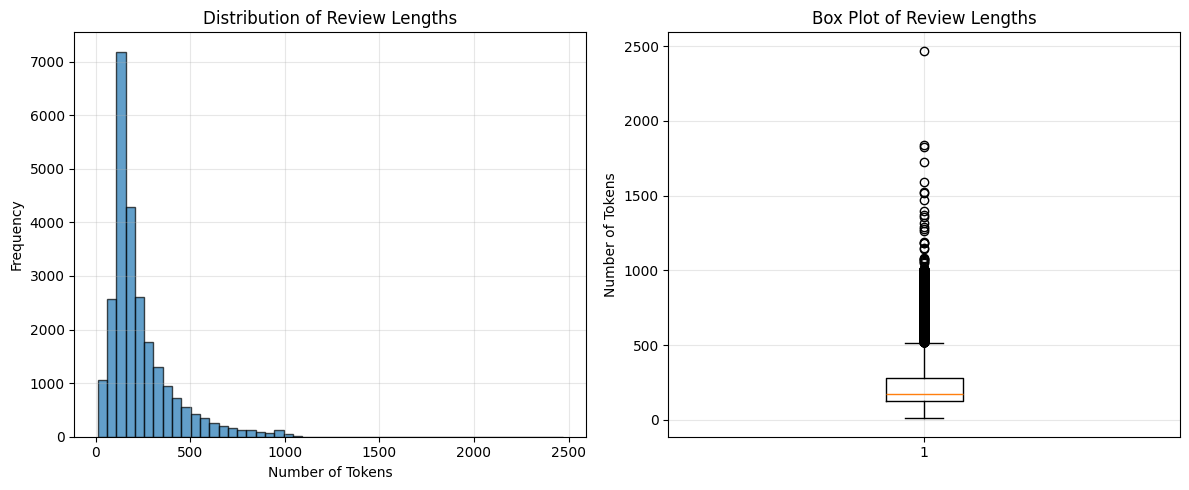

In [58]:
# Visualize distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(review_lengths, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Tokens')
plt.ylabel('Frequency')
plt.title('Distribution of Review Lengths')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(review_lengths, vert=True)
plt.ylabel('Number of Tokens')
plt.title('Box Plot of Review Lengths')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [59]:
# Set max_length based on analysis (covering ~90-95% of reviews)
max_length = int(np.percentile(review_lengths, 95))
print(f"\nRecommended max_length: {max_length}")
print(f"This covers approximately 95% of all reviews")


Recommended max_length: 595
This covers approximately 95% of all reviews


In [60]:
print("Encoding training data...")
x_train_list, len_train = [], []
for ex in dataset['train']:
    ids, L = encode_text(ex['text'], word_to_idx, max_length)
    x_train_list.append(ids)
    len_train.append(L)

x_train = torch.tensor(x_train_list, dtype=torch.long)
y_train = torch.tensor([ex['label'] for ex in dataset['train']], dtype=torch.float32)
len_train = torch.tensor(len_train, dtype=torch.long)

Encoding training data...


In [61]:
x_train,y_train

(tensor([[  10, 1533,   10,  ...,    0,    0,    0],
         [  10,  237, 1934,  ...,    0,    0,    0],
         [  45,   61,    6,  ...,    0,    0,    0],
         ...,
         [  11,   20,    3,  ...,    0,    0,    0],
         [   2, 2435,    5,  ...,   50,   16, 2026],
         [   2,   64, 4518,  ...,    0,    0,    0]]),
 tensor([0., 0., 0.,  ..., 1., 1., 1.]))

In [62]:
print("Encoding test data...")

x_test_list, len_test = [], []
for ex in dataset['test']:
    ids, L = encode_text(ex['text'], word_to_idx, max_length)
    x_test_list.append(ids)
    len_test.append(L)

x_test  = torch.tensor(x_test_list, dtype=torch.long)
y_test  = torch.tensor([ex['label'] for ex in dataset['test']], dtype=torch.float32)
len_test = torch.tensor(len_test, dtype=torch.long)

Encoding test data...


In [63]:
x_test,y_test

(tensor([[  10,  116,  967,  ...,    0,    0,    0],
         [ 278,    2,  727,  ...,    0,    0,    0],
         [  30,    4,  467,  ...,    0,    0,    0],
         ...,
         [  10,  183,  969,  ...,    0,    0,    0],
         [ 710,  233,    8,  ...,    0,    0,    0],
         [  10, 1031,   11,  ...,    0,    0,    0]]),
 tensor([0., 0., 0.,  ..., 1., 1., 1.]))

In [64]:
# Split training data into train and validation
x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

In [65]:
print(f"\nFinal training data shape: {x_train_final.shape}")
print(f"Validation data shape: {x_val.shape}")
print(f"Test data shape: {x_test.shape}")


Final training data shape: torch.Size([20000, 595])
Validation data shape: torch.Size([5000, 595])
Test data shape: torch.Size([25000, 595])


## 3. Create PyTorch Dataset and DataLoader

In [66]:
# Custom Dataset class
class IMDBDataset(torch.utils.data.Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.LongTensor(sequences)
        self.labels = torch.FloatTensor(labels)
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

# Create datasets
train_dataset = IMDBDataset(x_train_final, y_train_final)
val_dataset = IMDBDataset(x_val, y_val)
test_dataset = IMDBDataset(x_test, y_test)

In [67]:
PAD_ID = word_to_idx['<PAD>']
def collate_with_lengths(batch):
    sequences, labels = zip(*batch)
    sequences = torch.stack(sequences, dim=0)
    labels = torch.stack(labels, dim=0).float()

    # Compute lengths (number of non-PAD tokens)
    lengths = (sequences != PAD_ID).sum(dim=1).long()

    return sequences, labels, lengths

In [68]:
train_dataset.sequences

tensor([[  10, 4859,   11,  ...,    0,    0,    0],
        [ 101,    2, 2017,  ...,    0,    0,    0],
        [  21,    2, 7126,  ...,   15,   35,    1],
        ...,
        [  10,   26,  321,  ...,    0,    0,    0],
        [ 418,    6,   68,  ...,    0,    0,    0],
        [  10,   86,  208,  ...,    0,    0,    0]])

In [69]:
# Create data loaders
batch_size = 128
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True,drop_last=False,collate_fn=collate_with_lengths)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False,drop_last=False,collate_fn=collate_with_lengths)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False,drop_last=False,collate_fn=collate_with_lengths)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training batches: 157
Number of validation batches: 40
Number of test batches: 196


## 4. Build the LSTM Model

In [70]:
# Define the LSTM model
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, output_size=1,
                 num_layers=1, bidirectional=False, dropout=0.3, padding_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        direction = 2 if bidirectional else 1
        self.fc = nn.Linear(hidden_size * direction, output_size)  # logits

    def forward(self, x, lengths):
        e = self.embedding(x)  # (B, T, E)
        packed = pack_padded_sequence(e, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, (h_n, c_n) = self.lstm(packed)  # LSTM returns (h_n, c_n)
        if self.lstm.bidirectional:
            h_fwd = h_n[-2]  # (B, H)
            h_bwd = h_n[-1]  # (B, H)
            last_h = torch.cat([h_fwd, h_bwd], dim=1)  # (B, 2H)
        else:
            last_h = h_n[-1]  # (B, H)
        logits = self.fc(self.dropout(last_h)).squeeze(1)  # (B,)
        return logits

#Define hyperparameters
embedding_dim = 200
lstm_hidden_size = 128

# Create the model
model = SentimentLSTM(len(word_to_idx), embedding_dim, lstm_hidden_size, output_size=1, dropout=0.5)
model = model.to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

SentimentLSTM(
  (embedding): Embedding(20000, 200, padding_idx=0)
  (lstm): LSTM(200, 128, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Total parameters: 4169089


## 5. Define Loss Function and Optimizer

In [71]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001,weight_decay=1e-4)

print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")

Loss function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


## 6. Training Functions

In [72]:
def train_epoch(model, loader, device):
    model.train()
    total_loss = total_correct = total = 0
    for seqs, labels, lengths in loader:
        seqs, labels, lengths = seqs.to(device), labels.to(device).float(), lengths.to(device)
        optimizer.zero_grad()
        logits = model(seqs, lengths)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        with torch.no_grad():
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            total_correct += (preds == labels).sum().item()
            total += labels.size(0)
        total_loss += loss.item()
    return total_loss/len(loader), total_correct/total

@torch.no_grad()
def validate(model, loader, device):
    model.eval()
    total_loss = total_correct = total = 0
    for seqs, labels, lengths in loader:
        seqs, labels, lengths = seqs.to(device), labels.to(device).float(), lengths.to(device)
        logits = model(seqs, lengths)
        loss = criterion(logits, labels)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        total_correct += (preds == labels).sum().item()
        total += labels.size(0)
        total_loss += loss.item()
    return total_loss/len(loader), total_correct/total

## 7. Train the Model

In [73]:
# ---- Config ----
num_epochs = 100
patience = 10

best_ckpt_path = os.path.join("best_lstm_model.pt")       # only best model weights (state_dict)
best_full_ckpt_path = os.path.join("best_lstm_full.pt")   # full checkpoint (model+optimizer, etc.)
last_ckpt_path = os.path.join("last_lstm_epoch.pt")       # last epoch checkpoint (optional)
best_model_object_path = os.path.join("best_lstm_model_object.pt") #best model object checkpoint

In [74]:
# ---- Tracking ----
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

best_val_loss = float('inf')
patience_counter = 0
best_model_state = None
best_epoch = -1

In [75]:
print("Starting training...\n")

for epoch in range(num_epochs):
    # Your existing helpers
    train_loss, train_acc = train_epoch(model, train_loader, device)
    val_loss, val_acc = validate(model, val_loader, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"  Val   Loss: {val_loss:.4f}, Val   Acc: {val_acc:.4f}")

    # ---- Early stopping + Best checkpointing ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        patience_counter = 0

        # Keep an in-memory copy to restore later if you want
        best_model_state = deepcopy(model.state_dict())

        # Save best weights-only checkpoint
        torch.save(model.state_dict(), best_ckpt_path)

        # Save the entire model object
        torch.save(model, best_model_object_path)

        # (Optional) Save full training state for perfect reproducibility
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict() if 'optimizer' in globals() and optimizer is not None else None,
            "scheduler_state_dict": scheduler.state_dict() if 'scheduler' in globals() and scheduler is not None else None,
            "best_val_loss": best_val_loss,
            "train_losses": train_losses,
            "train_accuracies": train_accuracies,
            "val_losses": val_losses,
            "val_accuracies": val_accuracies,
        }, best_full_ckpt_path)

        print(f"  *** New best validation loss: {best_val_loss:.4f} (epoch {best_epoch}) → saved ***")
    else:
        patience_counter += 1
        print(f"  Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch+1}")
            print(f"Best validation loss: {best_val_loss:.4f} (epoch {best_epoch})")

            # Restore the best model in memory (optional but common)
            if best_model_state is not None:
                model.load_state_dict(best_model_state)
            break

    # (Optional) Save last-epoch checkpoint to resume training later if needed
    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if 'optimizer' in globals() and optimizer is not None else None,
        "scheduler_state_dict": scheduler.state_dict() if 'scheduler' in globals() and scheduler is not None else None,
    }, last_ckpt_path)

    print()

print("\nTraining completed!")
print(f"Best epoch: {best_epoch}, Best val loss: {best_val_loss:.4f}")

# ---- Ensure the best weights are persisted after loop ----
# If early stopping didn’t trigger, make sure to save the final best state again (safety).
if best_model_state is not None:
    model.load_state_dict(best_model_state)  # keep best in memory for immediate evaluation/inference
    torch.save(model.state_dict(), best_ckpt_path)  # re-save to be certain
    torch.save(model, best_model_object_path)  # re-save the model object

Starting training...



Epoch [1/100]
  Train Loss: 0.6592, Train Acc: 0.6078
  Val   Loss: 0.5994, Val   Acc: 0.6888
  *** New best validation loss: 0.5994 (epoch 1) → saved ***

Epoch [2/100]
  Train Loss: 0.5722, Train Acc: 0.7071
  Val   Loss: 0.5721, Val   Acc: 0.7068
  *** New best validation loss: 0.5721 (epoch 2) → saved ***

Epoch [3/100]
  Train Loss: 0.5052, Train Acc: 0.7597
  Val   Loss: 0.5283, Val   Acc: 0.7444
  *** New best validation loss: 0.5283 (epoch 3) → saved ***

Epoch [4/100]
  Train Loss: 0.4643, Train Acc: 0.7873
  Val   Loss: 0.4689, Val   Acc: 0.7930
  *** New best validation loss: 0.4689 (epoch 4) → saved ***

Epoch [5/100]
  Train Loss: 0.4519, Train Acc: 0.7990
  Val   Loss: 0.4887, Val   Acc: 0.7906
  Patience: 1/10

Epoch [6/100]
  Train Loss: 0.4149, Train Acc: 0.8196
  Val   Loss: 0.4459, Val   Acc: 0.8086
  *** New best validation loss: 0.4459 (epoch 6) → saved ***

Epoch [7/100]
  Train Loss: 0.3765, Train Acc: 0.8421
  Val   Loss: 0.4382, Val   Acc: 0.8082
  *** New best

## 9. Evaluate on Test Set

In [76]:
test_loss, test_accuracy = validate(model, test_loader, device)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Test Loss: 0.3677
Test Accuracy: 0.8434 (84.34%)


## 10. Test with Custom Reviews

In [77]:
def predict_sentiment(text, model, word_to_idx, max_length, device):
    model.eval()
    encoded, length = encode_text(text, word_to_idx, max_length)  # Get both ids and length
    sequence = torch.LongTensor(encoded).unsqueeze(0).to(device)
    lengths = torch.LongTensor([length]).to(device)  # Create lengths tensor
    
    with torch.no_grad():
        output = model(sequence, lengths)  # Pass both sequence and lengths
        prediction = torch.sigmoid(output).item()  # Apply sigmoid to get probability
    
    sentiment = "Positive" if prediction > 0.5 else "Negative"
    confidence = prediction if prediction > 0.5 else 1 - prediction
    
    return sentiment, confidence

# Test with custom reviews
custom_reviews = [
    "This movie was absolutely fantastic! I loved every minute of it.",
    "Terrible movie. Waste of time and money. Would not recommend.",
    "The acting was decent but the plot was confusing and boring.",
    "One of the best films I've ever seen. Highly recommended!",
    "Not good, not bad. Just average."
]

print("Testing custom reviews:\n")
for i, review in enumerate(custom_reviews, 1):
    sentiment, confidence = predict_sentiment(review, model, word_to_idx, max_length, device)
    print(f"Review {i}: {review}")
    print(f"Prediction: {sentiment} (confidence: {confidence:.4f})\n")

Testing custom reviews:

Review 1: This movie was absolutely fantastic! I loved every minute of it.
Prediction: Positive (confidence: 0.5658)

Review 2: Terrible movie. Waste of time and money. Would not recommend.
Prediction: Negative (confidence: 0.9872)

Review 3: The acting was decent but the plot was confusing and boring.
Prediction: Negative (confidence: 0.9427)

Review 4: One of the best films I've ever seen. Highly recommended!
Prediction: Positive (confidence: 0.9962)

Review 5: Not good, not bad. Just average.
Prediction: Negative (confidence: 0.7564)

